In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit, fsolve, brentq, root_scalar
from scipy.signal import find_peaks, savgol_filter, peak_widths
import scipy.constants as sc

#### Data Preparation & Setup:

In [2]:
#taking calibration voltages and frequencies from lab to use in frequency/voltage conversion:
cal_voltages = np.linspace(0, 5, 11)
cal_frequencies = np.array([1, 1.178, 1.357, 1.537, 1.717, 1.901, 2.082, 2.263, 2.444, 2.624, 2.8])

In [3]:
def lin(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin, cal_voltages, cal_frequencies)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
print(a, b)

0.36112727272727274 0.9974545454545448


In [4]:
f2v_err = np.sqrt(a_err**2 + b_err**2)

In [5]:
#calculating errors using calibration error and DAQ accuracy:
daq_err = 0.001
net_amp_err = np.sqrt(f2v_err**2 + daq_err**2)
net_amp_err

np.float64(0.0016200193823473926)

In [6]:
#loading amplitude data taken in lab:
solid_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/solid_amp_ch0_3.csv")
solid_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/solid_amp_ch1_3.csv")

small_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/small_amp_ch0_3.csv")
small_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/small_amp_ch1_3.csv")

medium_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/med_amp_ch0_3.csv")
medium_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/med_amp_ch1_3.csv")

big_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/big_amp_ch0_3.csv")
big_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/big_amp_ch1_3.csv")

In [7]:
#tidying up (removing empty columns):
solid_amplitudes_ch0 = solid_amplitudes_ch0.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')
solid_amplitudes_ch1 = solid_amplitudes_ch1.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')

small_amplitudes_ch0 = small_amplitudes_ch0.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')
small_amplitudes_ch1 = small_amplitudes_ch1.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')

medium_amplitudes_ch0 = medium_amplitudes_ch0.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')
medium_amplitudes_ch1 = medium_amplitudes_ch1.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')

big_amplitudes_ch0 = big_amplitudes_ch0.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')
big_amplitudes_ch1 = big_amplitudes_ch1.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')

In [8]:
#defining frequency range (khZ) and setting index in amplitude datframes to frequency in Hz for ease of calculations:
ind = np.linspace(1000, 2000, 500)
frequency_range = np.linspace(1, 2, 500)

In [9]:
solid_amplitudes_ch0_plot = solid_amplitudes_ch0.set_index(pd.Index(ind))
solid_amplitudes_ch1_plot = solid_amplitudes_ch1.set_index(pd.Index(ind))

small_amplitudes_ch0_plot = small_amplitudes_ch0.set_index(pd.Index(ind))
small_amplitudes_ch1_plot = small_amplitudes_ch1.set_index(pd.Index(ind))

medium_amplitudes_ch0_plot = medium_amplitudes_ch0.set_index(pd.Index(ind))
medium_amplitudes_ch1_plot = medium_amplitudes_ch1.set_index(pd.Index(ind))

big_amplitudes_ch0_plot = big_amplitudes_ch0.set_index(pd.Index(ind))
big_amplitudes_ch1_plot = big_amplitudes_ch1.set_index(pd.Index(ind))

#### Finding experimental resonances:

<Axes: >

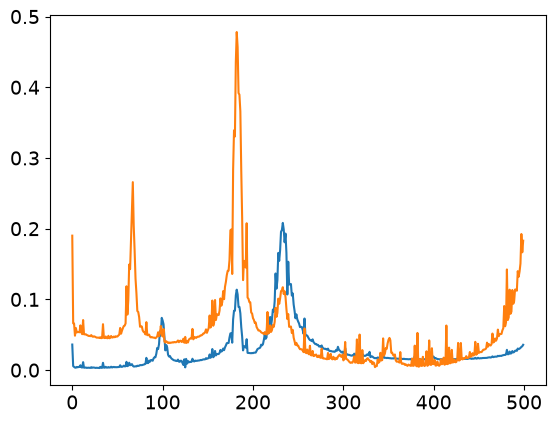

In [119]:
#amplitude spectrums were used to visually identify the peak regions, so that upper and lower bounds could be passed to a resonance finding function
small_amplitudes_ch0['10'].plot()
small_amplitudes_ch1['10'].plot()

In [11]:
#defining functions that will get resonance values for the two channels in the uncoupled (solid diaphragm) setup:
def get_res(amps, length, upper, lower):
    res_region = amps[length][(amps.index>lower)&(amps.index<upper)]
    res = frequency_range[np.where(amps==np.max(res_region))[0]]
    return res

In [12]:
def get_res_ch1(amps, length): #ch1 has no delta L dependence as this is the fixed length section
    upper = 1400
    lower = 1200
    res_region = amps[length][(amps.index>lower)&(amps.index<upper)]
    res = frequency_range[np.where(amps==np.max(res_region))[0]][0]
    return res

In [13]:
ch1_solid_res = []
for l in range(1, 15):
    res = get_res_ch1(solid_amplitudes_ch1_plot, str(l))
    ch1_solid_res.append(res)

In [14]:
ch0_solid_res = []

In [15]:
res_1 = get_res(solid_amplitudes_ch0_plot, '1', 1200, 1000)[0]
ch0_solid_res.append(res_1)

In [16]:
res_2 = get_res(solid_amplitudes_ch0_plot, '2', 1200, 1000)[0]
ch0_solid_res.append(res_2)

In [17]:
res_3 = get_res(solid_amplitudes_ch0_plot, '3', 1300, 1100)[0]
ch0_solid_res.append(res_3)

In [18]:
res_4 = get_res(solid_amplitudes_ch0_plot, '4', 1300, 1100)[0]
ch0_solid_res.append(res_4)

In [19]:
res_5 = get_res(solid_amplitudes_ch0_plot, '5', 1400, 1200)[0]
ch0_solid_res.append(res_5)

In [20]:
res_6 = get_res(solid_amplitudes_ch0_plot, '6', 1400, 1200)[0]
ch0_solid_res.append(res_6)

In [21]:
res_7 = get_res(solid_amplitudes_ch0_plot, '7', 1400, 1200)[0]
ch0_solid_res.append(res_7)

In [22]:
res_8 = get_res(solid_amplitudes_ch0_plot, '8', 1400, 1200)[0]
ch0_solid_res.append(res_8)

In [23]:
res_9 = get_res(solid_amplitudes_ch0_plot, '9', 1500, 1300)[0]
ch0_solid_res.append(res_9)

In [24]:
res_10 = get_res(solid_amplitudes_ch0_plot, '10', 1500, 1300)[0]
ch0_solid_res.append(res_10)

In [25]:
res_11 = get_res(solid_amplitudes_ch0_plot, '11', 1600, 1400)[0]
ch0_solid_res.append(res_11)

In [26]:
res_12 = get_res(solid_amplitudes_ch0_plot, '12', 1600, 1400)[0]
ch0_solid_res.append(res_12)

In [27]:
res_13 = get_res(solid_amplitudes_ch0_plot, '13', 1700, 1500)[0]
ch0_solid_res.append(res_13)

In [28]:
res_14 = get_res(solid_amplitudes_ch0_plot, '14', 1700, 1500)[0]
ch0_solid_res.append(res_14)

In [29]:
#delta L values as taken in lab
lengths = np.array([2, 4, 6, 7, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12.5, 13.5])

In [31]:
#linear fits to solid diaphragm values so that intercept can be found
def lin(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin, lengths, ch0_solid_res)
a_solid_res_ch0, b_solid_res_ch0 = popt
a_err_solid_res_ch0, b_err_solid_res_ch0 = np.sqrt(np.diag(pcov))

popt, pcov = curve_fit(lin, lengths, ch1_solid_res)
a_solid_res_ch1, b_solid_res_ch1 = popt
a_err_solid_res_ch1, b_err_solid_res_ch1 = np.sqrt(np.diag(pcov))

x_int = (b_solid_res_ch0 - b_solid_res_ch1)/(a_solid_res_ch1 - a_solid_res_ch0)
y_int = lin(x_int, a_solid_res_ch0, b_solid_res_ch0)

In [32]:
#error on intercept value:
np.sqrt(a_err_solid_res_ch0**2 + b_err_solid_res_ch0**2)

np.float64(0.023320023818359528)

In [33]:
x_int 

np.float64(8.774403768562905)

In [35]:
plt.rcParams.update({'font.size': 14})

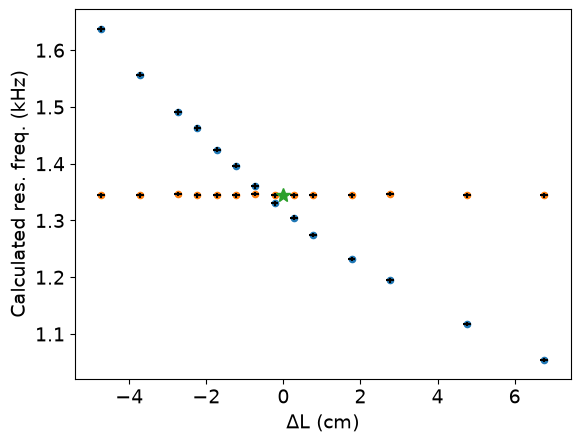

In [36]:
plt.scatter(-lengths+8.77, ch0_solid_res, s=20)
plt.scatter(-lengths+8.77, ch1_solid_res, s=20)

plt.errorbar(-lengths+8.77, ch0_solid_res, xerr = 0.1, yerr = np.sqrt((np.array(ch0_solid_res)*(0.0016/0.5))**2 + (0.001)**2), fmt='none', color='black')
plt.errorbar(-lengths+8.77, ch1_solid_res, xerr = 0.1, yerr = np.array(ch1_solid_res)*(0.0016/0.5), fmt='none', color='black')

# plt.plot(-lengths+8.77, lin(-lengths+8.77, -a_solid_res_ch0, b_solid_res_ch0))
# plt.plot(-lengths+8.77, lin(-lengths+8.77, a_solid_res_ch1, b_solid_res_ch1))

plt.plot(0, y_int, color='tab:green', marker='*', ms = 10, label = 'Intercept: ΔL=0 @ '+str(np.round(x_int, 2))+' cm', linestyle='None')

plt.xlabel('ΔL (cm)')
plt.ylabel('Calculated res. freq. (kHz)')
#plt.legend()
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/solid_disc.png", bbox_inches='tight')

In [37]:
#finding peaks for example plot included in report
amps = small_amplitudes_ch1_plot
length = '2' 

lower1 = 1100
upper1 = 1200
lower2 = 1300
upper2 = 1450

res1_region = amps[length][(amps.index>lower1)&(amps.index<upper1)]
a1 = np.max(res1_region)
res1 = frequency_range[np.where(amps==a1)[0]]

res2_region = amps[length][(amps.index>lower2)&(amps.index<upper2)]
a2 = np.max(res2_region)
res2 = frequency_range[np.where(amps==a2)[0]]

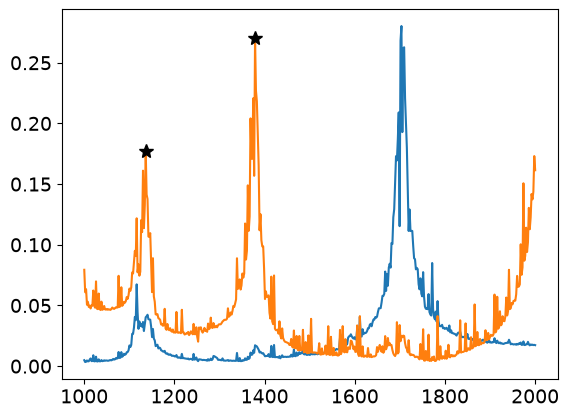

In [38]:
small_amplitudes_ch0_plot['2'].plot()
small_amplitudes_ch1_plot['2'].plot()
plt.plot(res1*1000, a1, marker = '*', color='black', ms=10)
plt.plot(res2*1000, a2, marker = '*', color='black', ms=10)

plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/amp_spectrum.png", bbox_inches='tight')

In [39]:
#defining a function to get resonances for the coupled system. using this function, 
#the same process was repeated as in the solid diaphragm case for the three 
#diaphragm hole sizes
def get_res_coupled(amps, length, lower1, upper1, lower2, upper2):
    res1_region = amps[length][(amps.index>lower1)&(amps.index<upper1)]
    res1 = frequency_range[np.where(amps==np.max(res1_region))[0]]

    res2_region = amps[length][(amps.index>lower2)&(amps.index<upper2)]
    res2 = frequency_range[np.where(amps==np.max(res2_region))[0]]
    return res1, res2

In [40]:
small_r1 = []
small_r2 = []

In [41]:
res1_1, res2_1 = get_res_coupled(small_amplitudes_ch1_plot, '1', 1100, 1200, 1300, 1450)
small_r1.append(res1_1[0])
small_r2.append(res2_1[0])

In [42]:
res1_2, res2_2 = get_res_coupled(small_amplitudes_ch1_plot, '2', 1100, 1200, 1300, 1450)
small_r1.append(res1_2[0])
small_r2.append(res2_2[0])

In [43]:
res1_3, res2_3 = get_res_coupled(small_amplitudes_ch1_plot, '3', 1150, 1250, 1300, 1450)
small_r1.append(res1_3[0])
small_r2.append(res2_3[0])

In [44]:
res1_4, res2_4 = get_res_coupled(small_amplitudes_ch1_plot, '4', 1200, 1300, 1300, 1450)
small_r1.append(res1_4[0])
small_r2.append(res2_4[0])

In [45]:
res1_5, res2_5 = get_res_coupled(small_amplitudes_ch1_plot, '5', 1250, 1350, 1350, 1450)
small_r1.append(res1_5[0])
small_r2.append(res2_5[0])

In [46]:
res1_6, res2_6 = get_res_coupled(small_amplitudes_ch1_plot, '6', 1250, 1350, 1350, 1450)
small_r1.append(res1_6[0])
small_r2.append(res2_6[0])

In [47]:
res1_7, res2_7 = get_res_coupled(small_amplitudes_ch1_plot, '7', 1300, 1400, 1400, 1500)
small_r1.append(res1_7[0])
small_r2.append(res2_7[0])

In [48]:
res1_8, res2_8 = get_res_coupled(small_amplitudes_ch1_plot, '8', 1300, 1400, 1400, 1500)
small_r1.append(res1_8[0])
small_r2.append(res2_8[0])

In [49]:
res1_9, res2_9 = get_res_coupled(small_amplitudes_ch1_plot, '9', 1300, 1400, 1400, 1500)
small_r1.append(res1_9[0])
small_r2.append(res2_9[0])

In [50]:
res1_10, res2_10 = get_res_coupled(small_amplitudes_ch1_plot, '10', 1300, 1400, 1400, 1500)
small_r1.append(res1_10[0])
small_r2.append(res2_10[0])

In [51]:
res1_11, res2_11 = get_res_coupled(small_amplitudes_ch1_plot, '11', 1350, 1450, 1450, 1550)
small_r1.append(res1_11[0])
small_r2.append(res2_11[0])

In [52]:
res1_12, res2_12 = get_res_coupled(small_amplitudes_ch1_plot, '12', 1350, 1450, 1450, 1550)
small_r1.append(res1_12[0])
small_r2.append(res2_12[0])

In [53]:
res1_13, res2_13 = get_res_coupled(small_amplitudes_ch1_plot, '13', 1350, 1450, 1550, 1650)
small_r1.append(res1_13[0])
small_r2.append(res2_13[0])

In [54]:
res1_14, res2_14 = get_res_coupled(small_amplitudes_ch0_plot, '14', 1300, 1400, 1600, 1800)
small_r1.append(res1_14[0])
small_r2.append(res2_14[0])

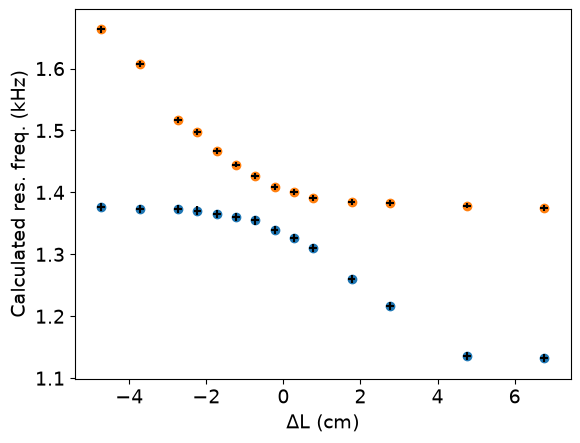

In [55]:
plt.scatter(-lengths+8.77, small_r1)
plt.scatter(-lengths+8.77, small_r2)
plt.errorbar(-lengths+8.77, small_r1, xerr = 0.1, yerr = np.sqrt((np.array(small_r1)*(0.0016/0.5))**2 + (0.005)**2), fmt='none', color='black')
plt.errorbar(-lengths+8.77, small_r2, xerr = 0.1, yerr = np.array(small_r2)*(0.0016/0.5), fmt='none', color='black')
plt.xlabel('ΔL (cm)')
plt.ylabel('Calculated res. freq. (kHz)')
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/small_disc.png", bbox_inches='tight')

In [127]:
#finding avoided crossing width:
small_widths = []
small_width_errs = []
for i, val in enumerate(small_r1):
    w = small_r2[i] -val
    small_widths.append(w)
    small_width_errs.append(np.sqrt((np.array(val)*(0.0016/0.5))**2 + (0.005)**2 + np.array(small_r2[i])*(0.0016/0.5))**2 + (0.005)**2)
small_min_crossing = np.min(small_widths)
small_min_crossing

np.float64(0.0701402805611222)

In [128]:
crossing_err = small_width_errs[np.where(small_widths == small_min_crossing)[0][0]]
crossing_err

np.float64(0.004576567097160251)

<Axes: >

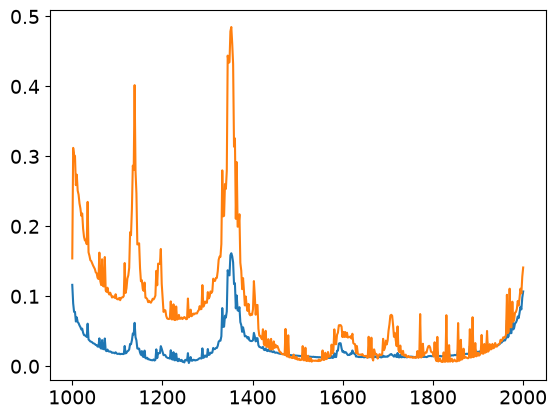

In [56]:
medium_amplitudes_ch0_plot['8'].plot()
medium_amplitudes_ch1_plot['8'].plot()

In [57]:
med_r1 = []
med_r2 = []

In [58]:
res1_1, res2_1 = get_res_coupled(medium_amplitudes_ch1_plot, '1', 1100, 1200, 1400, 1500)
med_r1.append(res1_1[0])
med_r2.append(res2_1[0])

In [59]:
res1_2, res2_2 = get_res_coupled(medium_amplitudes_ch1_plot, '2', 1150, 1250, 1450, 1550)
med_r1.append(res1_2[0])
med_r2.append(res2_2[0])

In [60]:
res1_3, res2_3 = get_res_coupled(medium_amplitudes_ch1_plot, '3', 1200, 1300, 1450, 1500)
med_r1.append(res1_3[0])
med_r2.append(res2_3[0])

In [61]:
res1_4, res2_4 = get_res_coupled(medium_amplitudes_ch1_plot, '4', 1200, 1300, 1500, 1600)
med_r1.append(res1_4[0])
med_r2.append(res2_4[0])

In [62]:
res1_5, res2_5 = get_res_coupled(medium_amplitudes_ch1_plot, '5', 1200, 1400, 1500, 1550)
med_r1.append(res1_5[0])
med_r2.append(res2_5[0])

In [63]:
res1_6, res2_6 = get_res_coupled(medium_amplitudes_ch1_plot, '6', 1200, 1400, 1500, 1550)
med_r1.append(res1_6[0])
med_r2.append(res2_6[0])

In [64]:
res1_7, res2_7 = get_res_coupled(medium_amplitudes_ch1_plot, '7', 1200, 1400, 1550, 1650)
med_r1.append(res1_7[0])
med_r2.append(res2_7[0])

In [65]:
res1_8, res2_8 = get_res_coupled(medium_amplitudes_ch1_plot, '8', 1200, 1400, 1550, 1650)
med_r1.append(res1_8[0])
med_r2.append(res2_8[0])

In [66]:
res1_9, res2_9 = get_res_coupled(medium_amplitudes_ch1_plot, '9', 1200, 1400, 1600, 1700)
med_r1.append(res1_9[0])
med_r2.append(res2_9[0])

In [67]:
res1_10, res2_10 = get_res_coupled(medium_amplitudes_ch1_plot, '10', 1200, 1400, 1600, 1700)
med_r1.append(res1_10[0])
med_r2.append(res2_10[0])

In [68]:
res1_11, res2_11 = get_res_coupled(medium_amplitudes_ch0_plot, '11', 1350, 1450, 1600, 1700)
med_r1.append(res1_11[0])
med_r2.append(res2_11[0])

In [69]:
res1_12, res2_12 = get_res_coupled(medium_amplitudes_ch0_plot, '12', 1350, 1450, 1650, 1750)
med_r1.append(res1_12[0])
med_r2.append(res2_12[0])

In [70]:
res1_13, res2_13 = get_res_coupled(medium_amplitudes_ch0_plot, '13', 1350, 1450, 1700, 1800)
med_r1.append(res1_13[0])
med_r2.append(res2_13[0])

In [71]:
res1_14, res2_14 = get_res_coupled(medium_amplitudes_ch0_plot, '14', 1350, 1450, 1700, 1800)
med_r1.append(res1_14[0])
med_r2.append(res2_14[0])

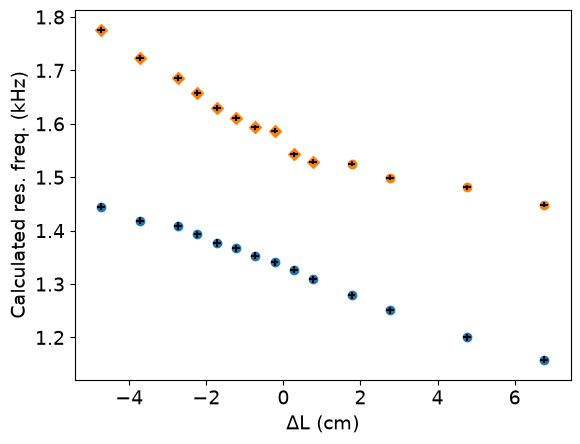

In [72]:
plt.scatter(-lengths + 8.77, med_r1)
plt.scatter(-lengths[0:4] + 8.77, med_r2[0:4])
plt.scatter(-lengths[4:] + 8.77, med_r2[4:], color='tab:orange', marker='D')
plt.errorbar(-lengths+8.77, med_r1, xerr = 0.1, yerr = np.sqrt((np.array(med_r1)*(0.0016/0.5))**2 + (0.005)**2), fmt='none', color='black')
plt.errorbar(-lengths+8.77, med_r2, xerr = 0.1, yerr = np.array(med_r2)*(0.0016/0.5), fmt='none', color='black')
plt.xlabel('ΔL (cm)')
plt.ylabel('Calculated res. freq. (kHz)')
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/medium_disc.png", bbox_inches='tight')

In [123]:
med_widths = []
med_width_errs = []
for i, val in enumerate(med_r1):
    w = med_r2[i] -val
    med_widths.append(w)#
    med_width_errs.append(np.sqrt((np.array(val)*(0.0016/0.5))**2 + (0.005)**2 + np.array(med_r2[i])*(0.0016/0.5))**2 + (0.005)**2)
med_min_crossing = np.min(med_widths)
med_min_crossing

np.float64(0.21643286573146292)

In [126]:
crossing_err = med_width_errs[np.where(med_widths == med_min_crossing)[0][0]]
crossing_err

np.float64(0.005005898243621512)

<Axes: >

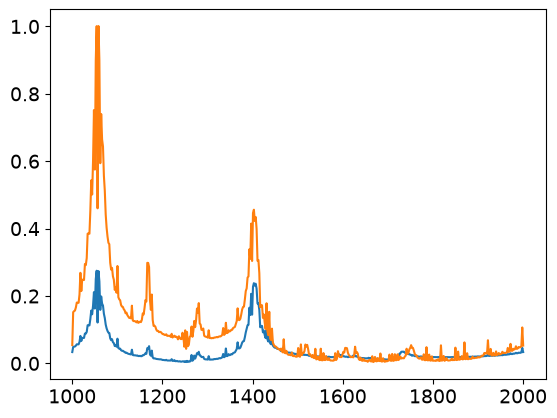

In [73]:
big_amplitudes_ch0_plot['12'].plot()
big_amplitudes_ch1_plot['12'].plot()

In [74]:
big_r1 = []
big_r2 = []

In [75]:
res1_1, res2_1 = get_res_coupled(big_amplitudes_ch1_plot, '1', 1100, 1200, 1400, 1500)
big_r1.append(res1_1[0])
big_r2.append(res2_1[0])

In [76]:
res1_2, res2_2 = get_res_coupled(big_amplitudes_ch1_plot, '2', 1150, 1250, 1450, 1550)
big_r1.append(res1_2[0])
big_r2.append(res2_2[0])

In [77]:
res1_3, res2_3 = get_res_coupled(big_amplitudes_ch1_plot, '3', 1200, 1300, 1500, 1600)
big_r1.append(res1_3[0])
big_r2.append(res2_3[0])

In [78]:
res1_4, res2_4 = get_res_coupled(big_amplitudes_ch1_plot, '4', 1200, 1300, 1500, 1600)
big_r1.append(res1_4[0])
big_r2.append(res2_4[0])

In [79]:
res1_5, res2_5 = get_res_coupled(big_amplitudes_ch1_plot, '5', 1250, 1350, 1550, 1650)
big_r1.append(res1_5[0])
big_r2.append(res2_5[0])

In [80]:
res1_6, res2_6 = get_res_coupled(big_amplitudes_ch1_plot, '6', 1250, 1350, 1550, 1650)
big_r1.append(res1_6[0])
big_r2.append(res2_6[0])

In [81]:
res1_7, res2_7 = get_res_coupled(big_amplitudes_ch1_plot, '7', 1300, 1400, 1550, 1650)
big_r1.append(res1_7[0])
big_r2.append(res2_7[0])

In [82]:
res1_8, res2_8 = get_res_coupled(big_amplitudes_ch1_plot, '8', 1300, 1400, 1550, 1600)
big_r1.append(res1_8[0])
big_r2.append(res2_8[0])

In [83]:
res1_9, res2_9 = get_res_coupled(big_amplitudes_ch1_plot, '9', 1300, 1400, 1650, 1700)
big_r1.append(res1_9[0])
big_r2.append(res2_9[0])

In [84]:
res1_10, res2_10 = get_res_coupled(big_amplitudes_ch1_plot, '10', 1350, 1450, 1700, 1800)
big_r1.append(res1_10[0])
big_r2.append(res2_10[0])

In [85]:
res1_11, res2_11 = get_res_coupled(big_amplitudes_ch1_plot, '11', 1350, 1450, 1700, 1800)
big_r1.append(res1_11[0])
big_r2.append(res2_11[0])

In [86]:
res1_12, res2_12 = get_res_coupled(big_amplitudes_ch1_plot, '12', 1350, 1450, 1700, 1800)
big_r1.append(res1_12[0])
big_r2.append(res2_12[0])

In [87]:
res1_13, res2_13 = get_res_coupled(big_amplitudes_ch0_plot, '13', 1400, 1500, 1700, 1800)
big_r1.append(res1_13[0])
big_r2.append(res2_13[0])

In [88]:
res1_14, res2_14 = get_res_coupled(big_amplitudes_ch0_plot, '14', 1400, 1500, 1700, 1800)
big_r1.append(res1_14[0])
big_r2.append(res2_14[0])

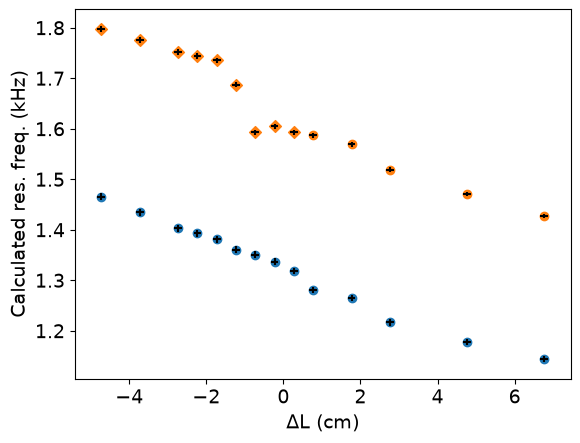

In [89]:
plt.scatter(-lengths+8.77, big_r1)
plt.scatter(-lengths[0:5]+8.77, big_r2[0:5], color='tab:orange')
plt.scatter(-lengths[5:15]+8.77, big_r2[5:15], color='tab:orange', marker='D')
plt.errorbar(-lengths+8.77, big_r1, xerr = 0.1, yerr = np.sqrt((np.array(big_r1)*(0.0016/0.5))**2 + (0.005)**2), fmt='none', color='black')
plt.errorbar(-lengths+8.77, big_r2, xerr = 0.1, yerr = np.array(big_r2)*(0.0016/0.5), fmt='none', color='black')
plt.xlabel('ΔL (cm)')
plt.ylabel('Calculated res. freq. (kHz)')
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/big_disc.png", bbox_inches='tight')

In [129]:
big_widths = []
big_width_errs = []
for i, val in enumerate(big_r1):
    w = big_r2[i] -val
    big_widths.append(w)#
    big_width_errs.append(np.sqrt((np.array(val)*(0.0016/0.5))**2 + (0.005)**2 + np.array(big_r2[i])*(0.0016/0.5))**2 + (0.005)**2)
big_min_crossing = np.min(big_widths)
big_min_crossing

np.float64(0.24248496993987967)

In [130]:
big_max_crossing = np.max(big_widths)
big_max_crossing

np.float64(0.35470941883767537)

In [132]:
big_mean_w = np.mean(big_widths)
big_mean_w

np.float64(0.3091898081878041)

In [133]:
mean_w_err = np.mean(big_width_errs)
mean_w_err

np.float64(0.005292182850028714)

#### Solving the quantum mechanical system:

In [90]:
#defining functions to convert between k (eigenvalue) and f (frequency)
def freq(k):
    return (k*343)/(2*np.pi)

def kval(f):
    return (2*np.pi*f)/343

In [91]:
#delta L in metres to use for equation
dl_m = [0.02, 0.04, 0.06, 0.07, 0.08, 0.085, 0.09, 0.1, 0.105, 0.11, 0.115, 0.125, 0.135]

dl_eq = []
for dl in dl_m:
    delta = -dl + 0.0877
    dl_eq.append(delta)

In [92]:
#defining function and parameters

L = 0.25 #fixed tube length measured to be 25 cm
a_val = [3*10**10, 100, 30, 0.3]

def qm_func(k, dL, a):
    return 1/np.tan(k*L) + 1/np.tan(k*(L + dL)) - 2*a/k


In [139]:
#solving for uncoupled system

f1_sols = []
f2_sols = []

k1_vals = []
k2_vals = []

i = 0

alpha = 3*10**10
delta_fixed = 0

for delta in dl_eq:
    k1 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(ch0_solid_res[i]*1000), xtol=30)
    k2 = root_scalar(qm_func, args=(delta_fixed, alpha), x0 = kval(ch1_solid_res[i]*1000), xtol=30)

    k1 = k1['root']
    k2 = k2['root']

    k1_vals.append(k1)
    k2_vals.append(k2)

    f1 = freq(k1)
    f2 = freq(k2)
    
    f1_sols.append((f1/2)/1000)
    f2_sols.append((f2/2)/1000)
    
    i+=1

In [140]:
dl_plot = []
for dl in dl_eq:
    dl = dl*100
    dl_plot.append(dl)

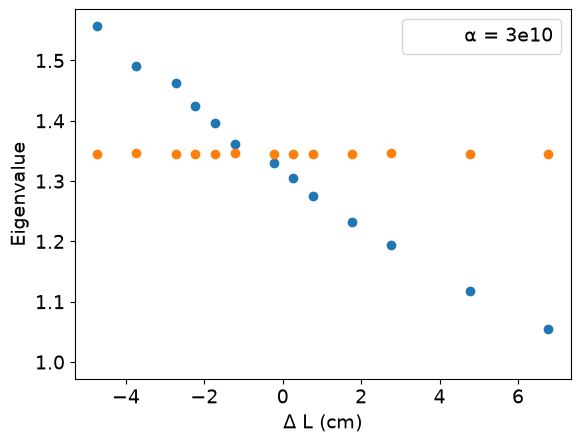

In [142]:
plt.scatter(dl_plot, f1_sols)
plt.scatter(dl_plot, f2_sols)
plt.plot(0, 1, marker='None', linestyle = 'None', label = 'α = 3e10')
plt.legend()
plt.xlabel('Δ L (cm)')
plt.ylabel('Eigenvalue')
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/theoretical_solid.png", bbox_inches='tight')

In [109]:
#solving for low coupling - this does not produce a plot that resembles the expected results and was not included in the report body

f1_sols = []
f2_sols = []

k1_vals = []
k2_vals = []

i = 0

alpha = 100

for delta in dl_eq:
    k1 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(small_r1[i]*1000), xtol=5)
    k2 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(small_r2[i]*1000), xtol=5)

    k1 = k1['root']
    k2 = k2['root']

    k1_vals.append(k1)
    k2_vals.append(k2)

    f1 = freq(k1)
    f2 = freq(k2)
    
    f1_sols.append(f1/1000)
    f2_sols.append(f2/1000)
    
    i+=1
                     

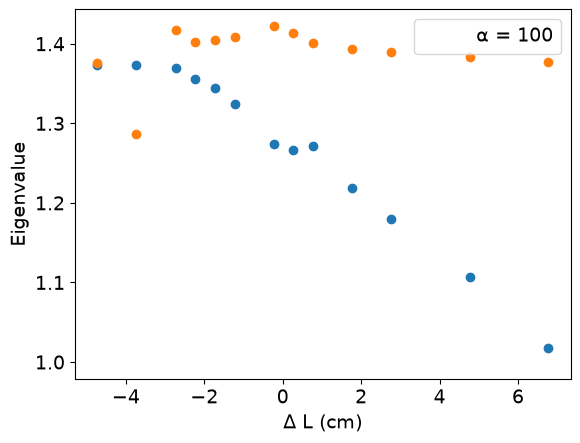

In [110]:
plt.scatter(dl_plot, f1_sols)
plt.scatter(dl_plot, f2_sols)
plt.plot(0, 1, marker='None', linestyle = 'None', label = 'α = 100')
plt.legend()
# plt.ylim(1000, 2000)
plt.xlabel('Δ L (cm)')
plt.ylabel('Eigenvalue')
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/theoretical_small.png", bbox_inches='tight')

In [134]:
#solving for medium coupling

f1_sols = []
f2_sols = []

k1_vals = []
k2_vals = []

i = 0

alpha = 30

for delta in dl_eq:
    k1 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(med_r1[i]*1000), xtol=10)
    k2 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(med_r2[i]*1000), xtol=10)

    k1 = k1['root']
    k2 = k2['root']

    k1_vals.append(k1)
    k2_vals.append(k2)

    f1 = freq(k1)
    f2 = freq(k2)
    
    f1_sols.append(f1/1000)
    f2_sols.append(f2/1000)
    
    i+=1
          

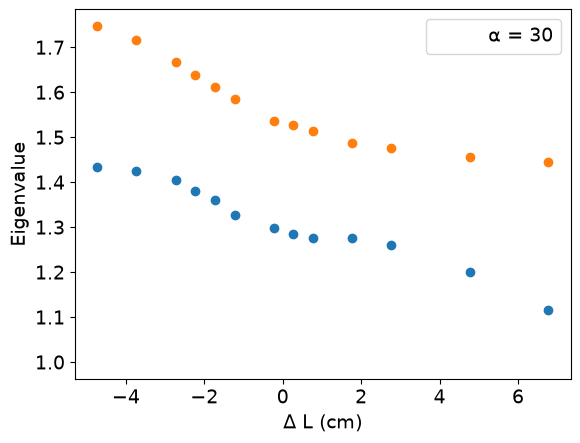

In [117]:
plt.scatter(dl_plot, f1_sols)
plt.scatter(dl_plot, f2_sols)
plt.xlabel('Δ L (cm)')
plt.ylabel('Eigenvalue')
plt.plot(0, 1, marker='None', linestyle = 'None', label = 'α = 30')
plt.legend()
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/theoretical_med.png", bbox_inches='tight')

In [136]:
med_th_widths = []
for i, val in enumerate(f1_sols):
    w = f2_sols[i] -val
    med_th_widths.append(w)#
med_th_min_crossing = np.min(med_th_widths)
med_th_min_crossing

np.float64(0.21215277964546253)

In [137]:
#solving for high coupling

f1_sols = []
f2_sols = []

k1_vals = []
k2_vals = []

i = 0

alpha = 0.3

for delta in dl_eq:
    k1 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(big_r1[i]*1000), xtol=10)
    k2 = root_scalar(qm_func, args=(delta, alpha), x0 = kval(big_r2[i]*1000), xtol=10)

    k1 = k1['root']
    k2 = k2['root']

    k1_vals.append(k1)
    k2_vals.append(k2)

    f1 = freq(k1)
    f2 = freq(k2)
    
    f1_sols.append(f1/1000)
    f2_sols.append(f2/1000)
    
    i+=1

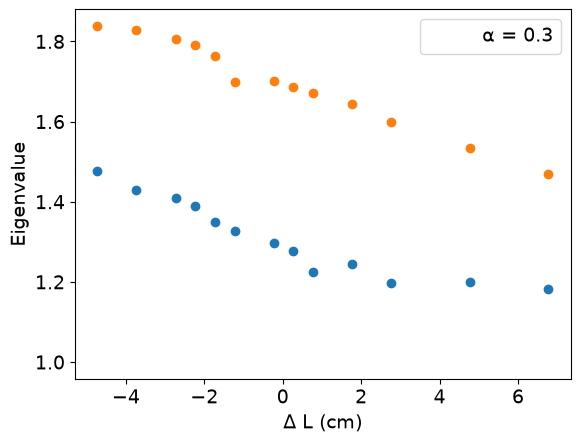

In [112]:
plt.scatter(dl_plot, f1_sols)
plt.scatter(dl_plot, f2_sols)
plt.xlabel('Δ L (cm)')
plt.ylabel('Eigenvalue')
plt.plot(0, 1, marker='None', linestyle = 'None', label = 'α = 0.3')
plt.legend()
plt.savefig("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/figures/theoretical_big.png", bbox_inches='tight')

In [138]:
big_th_widths = []
for i, val in enumerate(f1_sols):
    w = f2_sols[i] -val
    big_th_widths.append(w)#
big_th_mean_sep = np.min(big_th_widths)
big_th_mean_sep

np.float64(0.2852860966157722)